In [1]:
#basics
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings("ignore")

# Ensure project root (with LdaBoost package) is importable from simulations/
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from LdaBoost import LdaBoost
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import truncnorm


In [2]:
def make_classification_cov(n_samples, n_features, n_classes,
                            cov=None, shuffle=True, random_state=None):
    """
    Generate a synthetic multi-class classification dataset with correlated features.

    Parameters:
        n_samples (int): Total number of samples to generate.
        n_features (int): Number of numerical features (covariates).
        n_classes (int): Number of distinct classes (target categories).
        cov (array-like, shape (n_features,n_features) or None): Desired covariance matrix Σ for the features.
                                If None, the identity matrix is used (independent features).
        shuffle (bool): If True, shuffle the samples and labels. Default is True.
        random_state (int or np.random.RandomState, optional): Random seed or RNG for reproducibility.

    Returns:
        X (ndarray, shape (n_samples, n_features)): Generated feature matrix.
        y (ndarray, shape (n_samples,)): Class labels in {0,1,...,n_classes-1}.
    """
    # Set up random generator
    rng = np.random.RandomState(random_state)
    # Validate basic parameters
    n_samples = int(n_samples); n_features = int(n_features); n_classes = int(n_classes)
    if n_samples < 1 or n_features < 1 or n_classes < 1:
        raise ValueError("n_samples, n_features, and n_classes must be positive integers.")

    # Prepare covariance matrix
    if cov is None:
        Σ = np.eye(n_features)
    else:
        Σ = np.array(cov)
        if Σ.shape != (n_features, n_features):
            raise ValueError(f"Covariance matrix must be shape ({n_features},{n_features}).")
        if not np.allclose(Σ, Σ.T):
            raise ValueError("Covariance matrix must be symmetric.")

    # Determine samples per class (evenly distribute, last classes may have one extra)
    base, extra = divmod(n_samples, n_classes)

    # Define distinct means for each class (simple scheme: binary-coded offsets)
    offset = 1.0  # magnitude of class separation along each feature axis
    means = []
    for i in range(n_classes):
        mean_vec = np.zeros(n_features)
        # Set bits of class index to offset along features:
        for j in range(n_features):
            if (i >> j) & 1:
                mean_vec[j] = offset
        means.append(mean_vec)
    means = np.array(means)  # shape (n_classes, n_features)

    # Sample from Gaussian for each class
    X_parts = []
    y_parts = []
    for class_idx in range(n_classes):
        count = base + (1 if class_idx < extra else 0)
        if count <= 0:
            continue
        # Draw 'count' samples from N(mean, Σ)
        samples = rng.multivariate_normal(mean=means[class_idx], cov=Σ, size=count)
        X_parts.append(samples)
        y_parts.append(np.full(count, class_idx, dtype=int))

    # Stack data and labels
    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)

    # Shuffle the dataset if requested
    if shuffle:
        perm = rng.permutation(n_samples)
        X = X[perm]
        y = y[perm]

    return X, y

In [3]:
def generate_cov_matrix(size: int, mean: float, seed: int = None, std_dev: float = 0.1) -> np.ndarray:
    """
    Generate a symmetric covariance matrix with 1s on the diagonal
    and off-diagonal elements sampled from a truncated normal distribution
    with values in [-1, 1].

    Parameters:
    - size (int): Size of the square matrix.
    - mean (float): Mean for off-diagonal elements.
    - seed (int): Random seed (default: None).
    - std_dev (float): Standard deviation for sampling (default: 0.1).

    Returns:
    - np.ndarray: The generated covariance matrix.
    """
    if seed is not None:
        np.random.seed(seed)

    # Define truncated normal bounds
    a, b = (-1 - mean) / std_dev, (1 - mean) / std_dev

    matrix = np.eye(size)  # Start with identity matrix

    for i in range(size):
        for j in range(i + 1, size):
            value = truncnorm.rvs(a, b, loc=mean, scale=std_dev)
            matrix[i, j] = matrix[j, i] = value

    return matrix

cov_matrix = generate_cov_matrix(size=10, mean=0.5, seed=1, std_dev=1)
X, y = make_classification_cov(n_samples=200, n_features=10, n_classes=3,
                               cov=cov_matrix, random_state=42)

In [4]:
# Convert to DataFrame
df = pd.DataFrame(X)

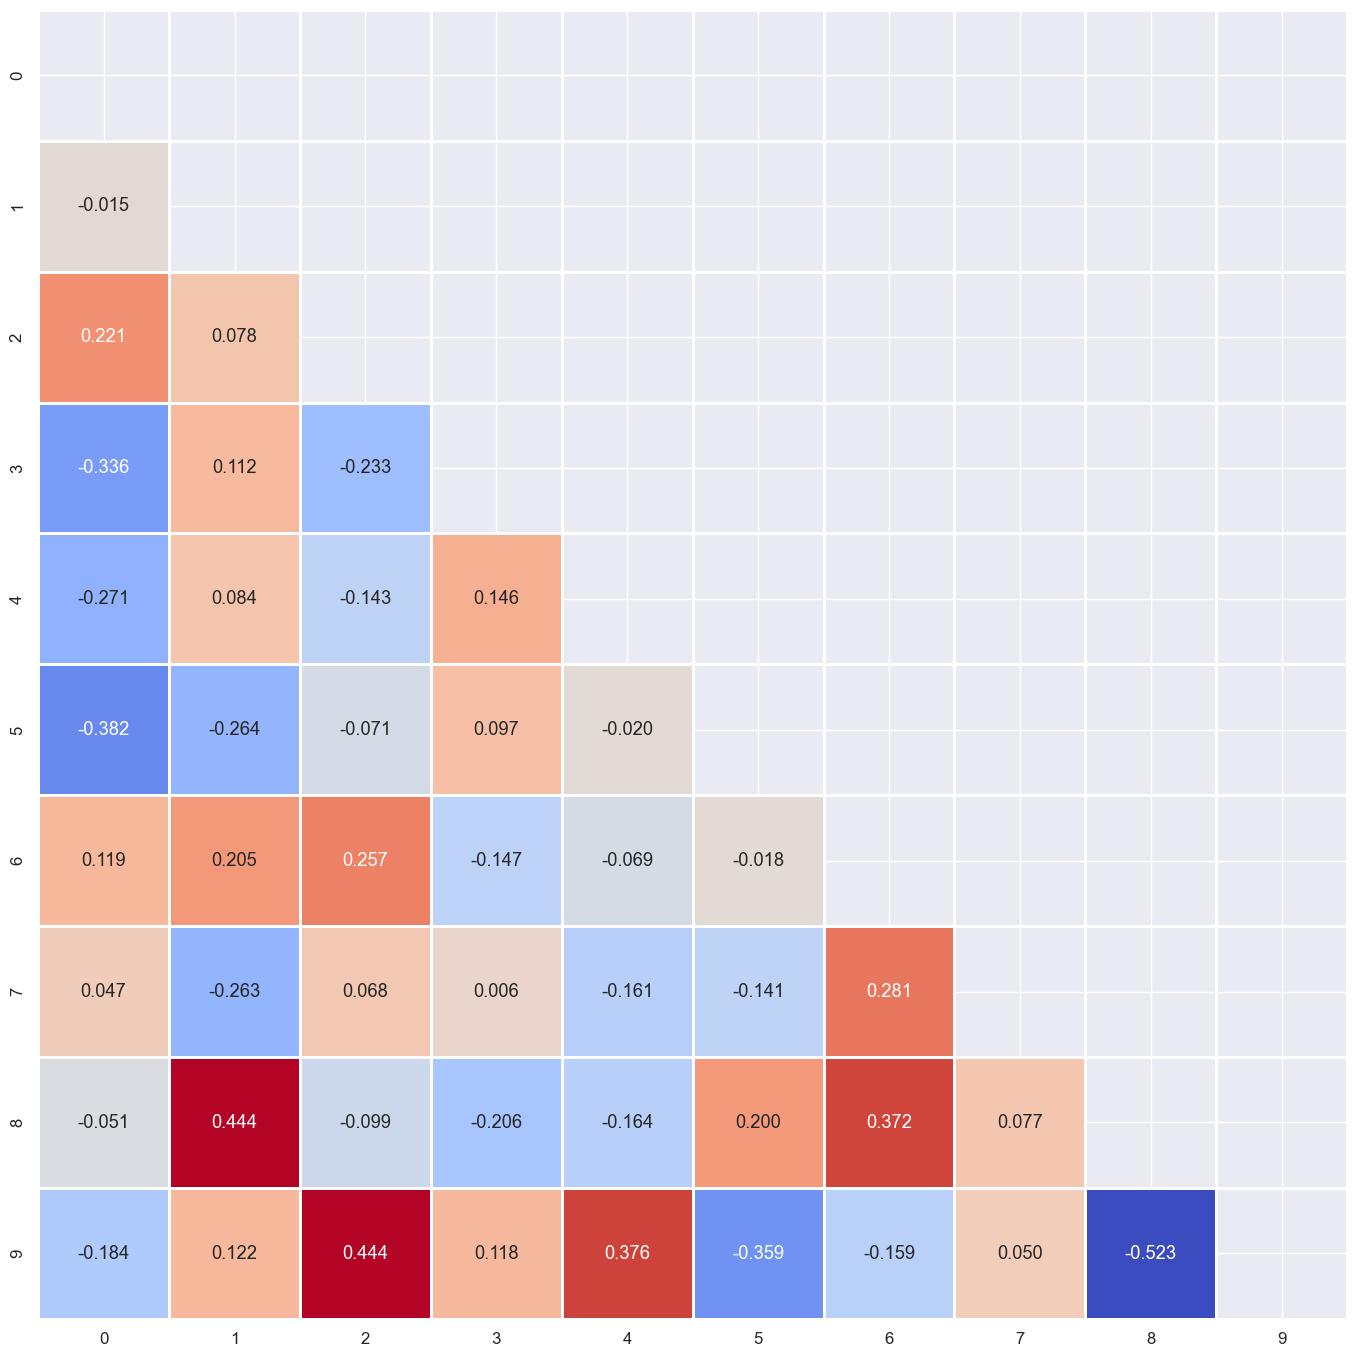

In [5]:
# Calcolo matrice di correlazione
correlation_matrix = df.corr()

# Maschera triangolare superiore
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot
sns.set(font_scale=1.1)
plt.figure(figsize=(17, 17))
sns.heatmap(correlation_matrix,  # Passa la matrice di correlazione
            annot=True,
            fmt=".3f",
            cmap="coolwarm",
            square=True,
            mask=mask,
            linewidths=1,
            cbar=False)
plt.show()

In [6]:
def plot_err(n_features: list, name: str, five_class_results: dict, target_name: str, dataset_name: str): 
    boost_val, boost_error, lda_val, lda_error, lda_preprocess_val, lda_preprocess_error = [], [], [], [], [], []

    for val in five_class_results.values():
        lda_val.append(round(np.mean(val["lda_accuracies"]),3))
        lda_error.append(round(np.std(val["lda_accuracies"]),3))
        boost_val.append(round(np.mean(val["boost_accuracies"]),3))
        boost_error.append(round(np.std(val["boost_accuracies"]),3))
        lda_preprocess_val.append(round(np.mean(val["lda_boost_accuracies"]),3))
        lda_preprocess_error.append(round(np.std(val["lda_boost_accuracies"]),3))

    plt.errorbar(np.log(n_features), lda_val, lda_error, marker="+", label="LdaBoost")
    plt.errorbar(np.log(n_features), boost_val, boost_error, marker="*", label="Boosting")
    plt.errorbar(np.log(n_features), lda_preprocess_val, lda_preprocess_error, marker="s", label="LdaPreprocess")

    plt.xlabel(f'Number of {name}')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy between different number of {name} for a {target_name} target')
    plt.legend()
    plt.xticks(np.log(n_features), labels=n_features)
    plt.savefig(f"Img/{dataset_name}_{name}_{target_name}.png")
    print("-"*12)
    print("Boost results:\n")
    print(boost_val, boost_error)
    print("-"*12)
    print("LdaBoost results:\n")
    print(lda_val, lda_error)
    print("-"*12)
    print("Lda preprocessing results:\n")
    print(lda_preprocess_val, lda_preprocess_error)
    plt.savefig("CONTROLLO.png")
    return plt.show()

--------

# Binary 10.000

In [7]:
n_features = [5, 50, 100, 300, 400]
target_name = "binary"
dataset_name = "classification"


binary_class_results = {}
for n in n_features:
    lda_accuracies = []
    boost_accuracies = []
    lda_boost_accuracies = []
    cov_matrix = generate_cov_matrix(size=n, mean=0.5, seed=1, std_dev=1)
    for i in range(1,6):
        X, y = make_classification_cov(n_samples=10000, n_features=n, n_classes=2,
                               cov=cov_matrix, random_state=i)  
        X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.3, random_state=1)
        ldaBoost = LdaBoost(n_estimators=500,
                            learning_rate=0.05,
                            max_depth=7,
                            random_state=1
                            )
        ldaBoost.fit(X_train, Y_train)
        lda_accuracies.append(accuracy_score(Y_test, ldaBoost.predict(X_test)))
        boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        boost.fit(X_train, Y_train)
        boost_accuracies.append(accuracy_score(Y_test, boost.predict(X_test)))
        lda = LinearDiscriminantAnalysis(n_components=1)
        X_train_lda = lda.fit_transform(X_train, Y_train)
        X_test_lda = lda.transform(X_test)
        lda_boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        lda_boost.fit(X_train_lda, Y_train)
        lda_boost_accuracies.append(accuracy_score(Y_test, lda_boost.predict(X_test_lda)))
        print(f"{n}, iterazione: {i}")
    binary_class_results[n] = {"lda_accuracies": lda_accuracies,
                             "boost_accuracies" : boost_accuracies,
                             "lda_boost_accuracies" : lda_boost_accuracies
                            }

5, iterazione: 1
5, iterazione: 2
5, iterazione: 3
5, iterazione: 4
5, iterazione: 5
50, iterazione: 1
50, iterazione: 2
50, iterazione: 3
50, iterazione: 4
50, iterazione: 5
100, iterazione: 1
100, iterazione: 2
100, iterazione: 3
100, iterazione: 4
100, iterazione: 5
300, iterazione: 1
300, iterazione: 2
300, iterazione: 3
300, iterazione: 4
300, iterazione: 5
400, iterazione: 1
400, iterazione: 2
400, iterazione: 3
400, iterazione: 4
400, iterazione: 5


------------
Boost results:

[0.783, 0.629, 0.581, 0.544, 0.545] [0.011, 0.013, 0.009, 0.013, 0.006]
------------
LdaBoost results:

[0.785, 0.71, 0.658, 0.588, 0.58] [0.007, 0.004, 0.005, 0.006, 0.005]
------------
Lda preprocessing results:

[0.773, 0.697, 0.639, 0.578, 0.57] [0.008, 0.01, 0.011, 0.008, 0.007]


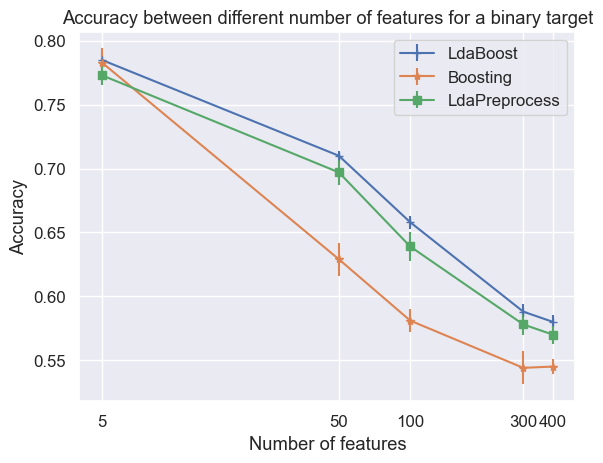

In [8]:
plot = plot_err(n_features, "features", binary_class_results, target_name, dataset_name)

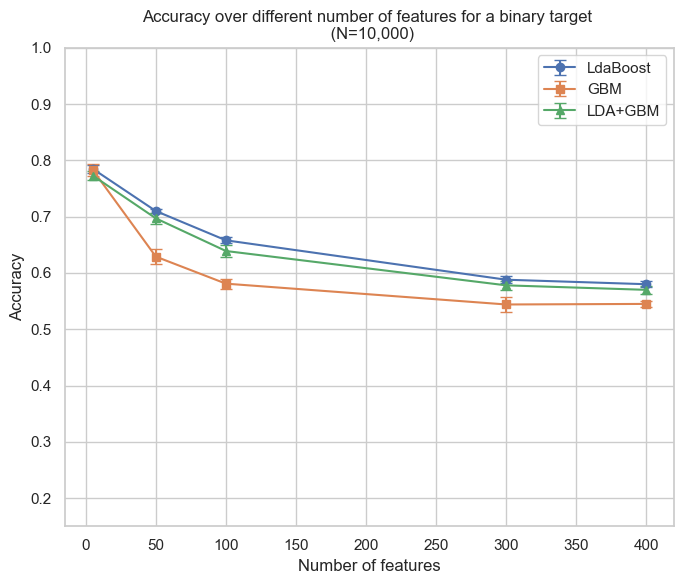

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Numero di feature considerate
features = [5, 50, 100, 300, 400]

# ------------------------------
# Accuratezze e barre d’errore
# ------------------------------
# Boosting (GBM standard)
boost_acc = [0.783, 0.629, 0.581, 0.544, 0.545]
boost_err = [0.011, 0.013, 0.009, 0.013, 0.006]

# LdaBoost
ldaboost_acc = [0.785, 0.71, 0.658, 0.588, 0.58]
ldaboost_err = [0.007, 0.004, 0.005, 0.006, 0.005]

# LdaPreprocess (LDA + GBM)
ldaprep_acc = [0.773, 0.697, 0.639, 0.578, 0.57] 
ldaprep_err = [0.008, 0.01, 0.011, 0.008, 0.007]

# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(7, 6))

plt.errorbar(
    features, ldaboost_acc, yerr=ldaboost_err,
    marker='o', linestyle='-', label='LdaBoost', capsize=4
)
plt.errorbar(
    features, boost_acc, yerr=boost_err,
    marker='s', linestyle='-', label='GBM', capsize=4
)
plt.errorbar(
    features, ldaprep_acc, yerr=ldaprep_err,
    marker='^', linestyle='-', label='LDA+GBM', capsize=4
)

# Impostiamo il range dell'asse y
plt.ylim(0.15, 1)

plt.title('Accuracy over different number of features for a binary target \n (N=10,000)')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Accuracy over different number of features for a binary target (N=10,000).pdf")
plt.show()

----------

# Medium Correlation

In [26]:
n_features = [5, 50, 100, 300, 400]
target_name = "multiclass"
dataset_name = "classification"

In [27]:
five_class_results = {}
for n in n_features:
    lda_accuracies = []
    boost_accuracies = []
    lda_boost_accuracies = []
    cov_matrix = generate_cov_matrix(size=n, mean=0.5, seed=1, std_dev=1)
    for i in range(1,6):
        X, y = make_classification_cov(n_samples=1500, n_features=n, n_classes=5,
                               cov=cov_matrix, random_state=i)  
        X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.3, random_state=1)
        ldaBoost = LdaBoost(n_estimators=500,
                            learning_rate=0.05,
                            max_depth=7,
                            random_state=1
                            )
        ldaBoost.fit(X_train, Y_train)
        lda_accuracies.append(accuracy_score(Y_test, ldaBoost.predict(X_test)))
        boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        boost.fit(X_train, Y_train)
        boost_accuracies.append(accuracy_score(Y_test, boost.predict(X_test)))
        lda = LinearDiscriminantAnalysis(n_components=4)
        X_train_lda = lda.fit_transform(X_train, Y_train)
        X_test_lda = lda.transform(X_test)
        lda_boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        lda_boost.fit(X_train_lda, Y_train)
        lda_boost_accuracies.append(accuracy_score(Y_test, lda_boost.predict(X_test_lda)))
        print(f"{n}, iterazione: {i}")
    five_class_results[n] = {"lda_accuracies": lda_accuracies,
                             "boost_accuracies" : boost_accuracies,
                             "lda_boost_accuracies" : lda_boost_accuracies
                            }

5, iterazione: 1
5, iterazione: 2
5, iterazione: 3
5, iterazione: 4
5, iterazione: 5
50, iterazione: 1
50, iterazione: 2
50, iterazione: 3
50, iterazione: 4
50, iterazione: 5
100, iterazione: 1
100, iterazione: 2
100, iterazione: 3
100, iterazione: 4
100, iterazione: 5
300, iterazione: 1
300, iterazione: 2
300, iterazione: 3
300, iterazione: 4
300, iterazione: 5
400, iterazione: 1
400, iterazione: 2
400, iterazione: 3
400, iterazione: 4
400, iterazione: 5


------------
Boost results:

[0.472, 0.253, 0.231, 0.224, 0.197] [0.016, 0.01, 0.022, 0.026, 0.015]
------------
LdaBoost results:

[0.51, 0.369, 0.301, 0.258, 0.243] [0.026, 0.014, 0.01, 0.02, 0.018]
------------
Lda preprocessing results:

[0.517, 0.377, 0.302, 0.263, 0.244] [0.016, 0.019, 0.016, 0.019, 0.018]


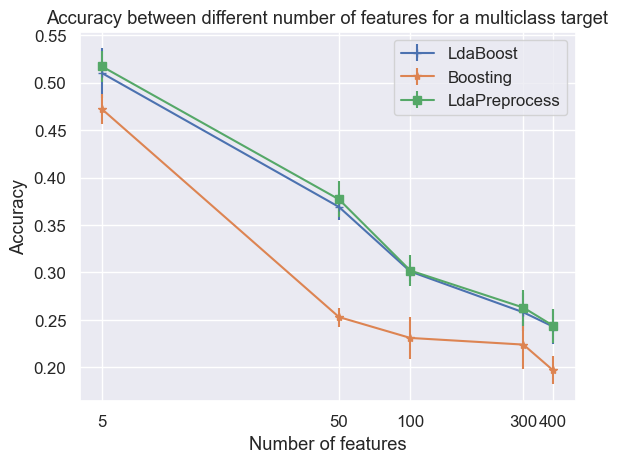

In [28]:
plot = plot_err(n_features, "features", five_class_results, target_name, dataset_name)

-----

## low correlation 0.2

5, iterazione: 1
5, iterazione: 2
5, iterazione: 3
5, iterazione: 4
5, iterazione: 5
50, iterazione: 1
50, iterazione: 2
50, iterazione: 3
50, iterazione: 4
50, iterazione: 5
100, iterazione: 1
100, iterazione: 2
100, iterazione: 3
100, iterazione: 4
100, iterazione: 5
300, iterazione: 1
300, iterazione: 2
300, iterazione: 3
300, iterazione: 4
300, iterazione: 5
400, iterazione: 1
400, iterazione: 2
400, iterazione: 3
400, iterazione: 4
400, iterazione: 5
------------
Boost results:

[0.709, 0.573, 0.543, 0.521, 0.538] [0.013, 0.032, 0.031, 0.019, 0.022]
------------
LdaBoost results:

[0.686, 0.718, 0.624, 0.531, 0.54] [0.037, 0.029, 0.022, 0.035, 0.031]
------------
Lda preprocessing results:

[0.684, 0.717, 0.627, 0.531, 0.54] [0.04, 0.025, 0.019, 0.035, 0.031]


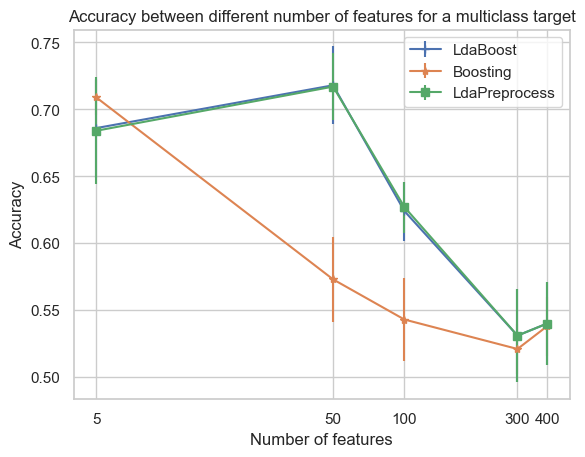

In [10]:
n_features = [5, 50, 100, 300, 400]
target_name = "multiclass"
dataset_name = "binary"

five_class_results = {}
for n in n_features:
    lda_accuracies = []
    boost_accuracies = []
    lda_boost_accuracies = []
    cov_matrix = generate_cov_matrix(size=n, mean=0.2, seed=1, std_dev=1)
    for i in range(1,6):
        X, y = make_classification_cov(n_samples=1000, n_features=n, n_classes=2,
                               cov=cov_matrix, random_state=i)  
        X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.3, random_state=1)
        ldaBoost = LdaBoost(n_estimators=500,
                            learning_rate=0.05,
                            max_depth=7,
                            random_state=1
                            )
        ldaBoost.fit(X_train, Y_train)
        lda_accuracies.append(accuracy_score(Y_test, ldaBoost.predict(X_test)))
        boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        boost.fit(X_train, Y_train)
        boost_accuracies.append(accuracy_score(Y_test, boost.predict(X_test)))
        lda = LinearDiscriminantAnalysis(n_components=1)
        X_train_lda = lda.fit_transform(X_train, Y_train)
        X_test_lda = lda.transform(X_test)
        lda_boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        lda_boost.fit(X_train_lda, Y_train)
        lda_boost_accuracies.append(accuracy_score(Y_test, lda_boost.predict(X_test_lda)))
        print(f"{n}, iterazione: {i}")
    five_class_results[n] = {"lda_accuracies": lda_accuracies,
                             "boost_accuracies" : boost_accuracies,
                             "lda_boost_accuracies" : lda_boost_accuracies
                            }
    
plot = plot_err(n_features, "features", five_class_results, target_name, dataset_name)

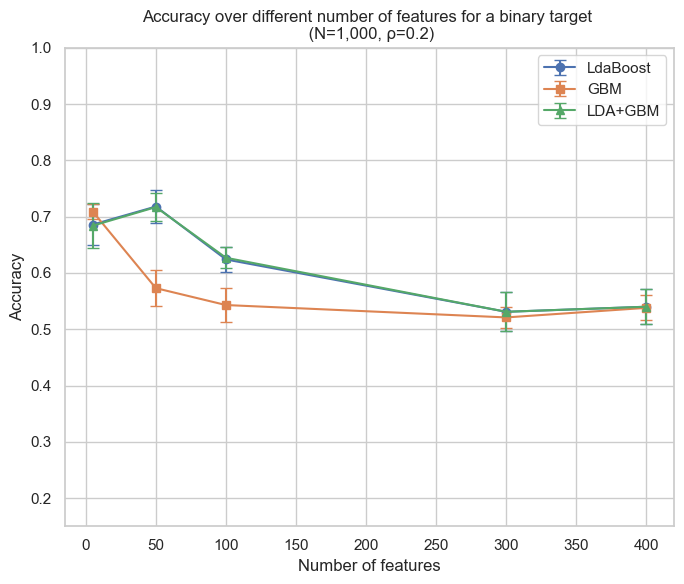

In [14]:
# Boost results:

# [0.709, 0.573, 0.543, 0.521, 0.538] [0.013, 0.032, 0.031, 0.019, 0.022]
# ------------
# LdaBoost results:

# [0.686, 0.718, 0.624, 0.531, 0.54] [0.037, 0.029, 0.022, 0.035, 0.031]
# ------------
# Lda preprocessing results:

# [0.684, 0.717, 0.627, 0.531, 0.54] [0.04, 0.025, 0.019, 0.035, 0.031]


import matplotlib.pyplot as plt

# Numero di feature considerate
features = [5, 50, 100, 300, 400]

# ------------------------------
# Accuratezze e barre d’errore
# ------------------------------
# Boosting (GBM standard)
boost_acc = [0.709, 0.573, 0.543, 0.521, 0.538]
boost_err = [0.013, 0.032, 0.031, 0.019, 0.022]

# LdaBoost
ldaboost_acc = [0.686, 0.718, 0.624, 0.531, 0.54] 
ldaboost_err = [0.037, 0.029, 0.022, 0.035, 0.031]

# LdaPreprocess (LDA + GBM)
ldaprep_acc = [0.684, 0.717, 0.627, 0.531, 0.54] 
ldaprep_err = [0.04, 0.025, 0.019, 0.035, 0.031]
# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(7, 6))

plt.errorbar(
    features, ldaboost_acc, yerr=ldaboost_err,
    marker='o', linestyle='-', label='LdaBoost', capsize=4
)
plt.errorbar(
    features, boost_acc, yerr=boost_err,
    marker='s', linestyle='-', label='GBM', capsize=4
)
plt.errorbar(
    features, ldaprep_acc, yerr=ldaprep_err,
    marker='^', linestyle='-', label='LDA+GBM', capsize=4
)

# Impostiamo il range dell'asse y
plt.ylim(0.15, 1)

plt.title('Accuracy over different number of features for a binary target \n (N=1,000, ρ=0.2)')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Accuracy over different number of features for a binary target low correlation.pdf")
plt.show()

----

## High correlation 0.7

5, iterazione: 1
5, iterazione: 2
5, iterazione: 3
5, iterazione: 4
5, iterazione: 5
50, iterazione: 1
50, iterazione: 2
50, iterazione: 3
50, iterazione: 4
50, iterazione: 5
100, iterazione: 1
100, iterazione: 2
100, iterazione: 3
100, iterazione: 4
100, iterazione: 5
300, iterazione: 1
300, iterazione: 2
300, iterazione: 3
300, iterazione: 4
300, iterazione: 5
400, iterazione: 1
400, iterazione: 2
400, iterazione: 3
400, iterazione: 4
400, iterazione: 5
------------
Boost results:

[0.748, 0.558, 0.554, 0.52, 0.508] [0.026, 0.013, 0.037, 0.032, 0.032]
------------
LdaBoost results:

[0.721, 0.633, 0.677, 0.527, 0.548] [0.023, 0.025, 0.04, 0.023, 0.044]
------------
Lda preprocessing results:

[0.717, 0.63, 0.673, 0.527, 0.548] [0.019, 0.026, 0.039, 0.023, 0.044]


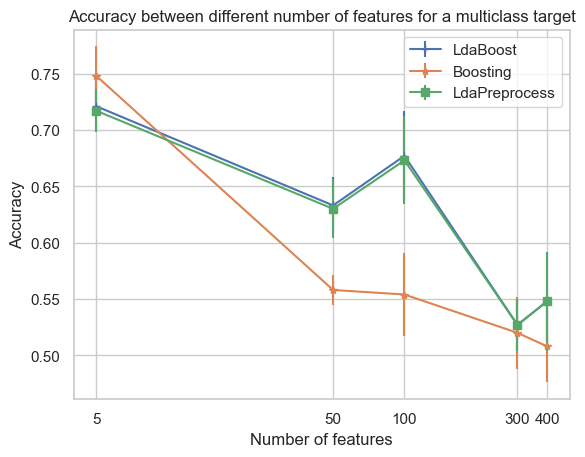

In [11]:
n_features = [5, 50, 100, 300, 400]
target_name = "multiclass"
dataset_name = "binary"

five_class_results = {}
for n in n_features:
    lda_accuracies = []
    boost_accuracies = []
    lda_boost_accuracies = []
    cov_matrix = generate_cov_matrix(size=n, mean=0.7, seed=1, std_dev=1)
    for i in range(1,6):
        X, y = make_classification_cov(n_samples=1000, n_features=n, n_classes=2,
                               cov=cov_matrix, random_state=i)  
        X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.3, random_state=1)
        ldaBoost = LdaBoost(n_estimators=500,
                            learning_rate=0.05,
                            max_depth=7,
                            random_state=1
                            )
        ldaBoost.fit(X_train, Y_train)
        lda_accuracies.append(accuracy_score(Y_test, ldaBoost.predict(X_test)))
        boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        boost.fit(X_train, Y_train)
        boost_accuracies.append(accuracy_score(Y_test, boost.predict(X_test)))
        lda = LinearDiscriminantAnalysis(n_components=1)
        X_train_lda = lda.fit_transform(X_train, Y_train)
        X_test_lda = lda.transform(X_test)
        lda_boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        lda_boost.fit(X_train_lda, Y_train)
        lda_boost_accuracies.append(accuracy_score(Y_test, lda_boost.predict(X_test_lda)))
        print(f"{n}, iterazione: {i}")
    five_class_results[n] = {"lda_accuracies": lda_accuracies,
                             "boost_accuracies" : boost_accuracies,
                             "lda_boost_accuracies" : lda_boost_accuracies
                            }
    
plot = plot_err(n_features, "features", five_class_results, target_name, dataset_name)

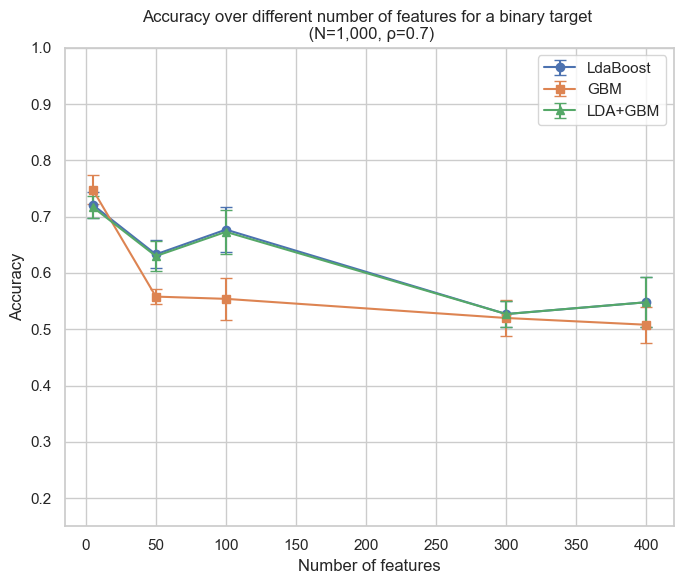

In [13]:
# Boost results:

# [0.748, 0.558, 0.554, 0.52, 0.508] [0.026, 0.013, 0.037, 0.032, 0.032]
# ------------
# LdaBoost results:

# [0.721, 0.633, 0.677, 0.527, 0.548] [0.023, 0.025, 0.04, 0.023, 0.044]
# ------------
# Lda preprocessing results:

# [0.717, 0.63, 0.673, 0.527, 0.548] [0.019, 0.026, 0.039, 0.023, 0.044]


import matplotlib.pyplot as plt

# Numero di feature considerate
features = [5, 50, 100, 300, 400]

# ------------------------------
# Accuratezze e barre d’errore
# ------------------------------
# Boosting (GBM standard)
boost_acc = [0.748, 0.558, 0.554, 0.52, 0.508]
boost_err = [0.026, 0.013, 0.037, 0.032, 0.032]

# LdaBoost
ldaboost_acc = [0.721, 0.633, 0.677, 0.527, 0.548] 
ldaboost_err = [0.023, 0.025, 0.04, 0.023, 0.044]

# LdaPreprocess (LDA + GBM)
ldaprep_acc = [0.717, 0.63, 0.673, 0.527, 0.548]
ldaprep_err = [0.019, 0.026, 0.039, 0.023, 0.044]
# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(7, 6))

plt.errorbar(
    features, ldaboost_acc, yerr=ldaboost_err,
    marker='o', linestyle='-', label='LdaBoost', capsize=4
)
plt.errorbar(
    features, boost_acc, yerr=boost_err,
    marker='s', linestyle='-', label='GBM', capsize=4
)
plt.errorbar(
    features, ldaprep_acc, yerr=ldaprep_err,
    marker='^', linestyle='-', label='LDA+GBM', capsize=4
)

# Impostiamo il range dell'asse y
plt.ylim(0.15, 1)

plt.title('Accuracy over different number of features for a binary target \n (N=1,000, ρ=0.7)')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Accuracy over different number of features for a binary target high correlation.pdf")
plt.show()

------

# Binary classification

In [29]:
n_features = [5, 50, 100, 300, 400]
target_name = "binary"
dataset_name = "classification"

In [31]:
binary_class_results = {}
for n in n_features:
    lda_accuracies = []
    boost_accuracies = []
    lda_boost_accuracies = []
    cov_matrix = generate_cov_matrix(size=n, mean=0.5, seed=1, std_dev=1)
    for i in range(1,6):
        X, y = make_classification_cov(n_samples=1500, n_features=n, n_classes=2,
                               cov=cov_matrix, random_state=i)  
        X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=.3, random_state=1)
        ldaBoost = LdaBoost(n_estimators=500,
                            learning_rate=0.05,
                            max_depth=7,
                            random_state=1
                            )
        ldaBoost.fit(X_train, Y_train)
        lda_accuracies.append(accuracy_score(Y_test, ldaBoost.predict(X_test)))
        boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        boost.fit(X_train, Y_train)
        boost_accuracies.append(accuracy_score(Y_test, boost.predict(X_test)))
        lda = LinearDiscriminantAnalysis(n_components=1)
        X_train_lda = lda.fit_transform(X_train, Y_train)
        X_test_lda = lda.transform(X_test)
        lda_boost = GradientBoostingClassifier(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=7,
            random_state=1
            )
        lda_boost.fit(X_train_lda, Y_train)
        lda_boost_accuracies.append(accuracy_score(Y_test, lda_boost.predict(X_test_lda)))
        print(f"{n}, iterazione: {i}")
    binary_class_results[n] = {"lda_accuracies": lda_accuracies,
                             "boost_accuracies" : boost_accuracies,
                             "lda_boost_accuracies" : lda_boost_accuracies
                            }

5, iterazione: 1
5, iterazione: 2
5, iterazione: 3
5, iterazione: 4
5, iterazione: 5
50, iterazione: 1
50, iterazione: 2
50, iterazione: 3
50, iterazione: 4
50, iterazione: 5
100, iterazione: 1
100, iterazione: 2
100, iterazione: 3
100, iterazione: 4
100, iterazione: 5
300, iterazione: 1
300, iterazione: 2
300, iterazione: 3
300, iterazione: 4
300, iterazione: 5
400, iterazione: 1
400, iterazione: 2
400, iterazione: 3
400, iterazione: 4
400, iterazione: 5


------------
Boost results:

[0.755, 0.598, 0.571, 0.54, 0.524] [0.019, 0.02, 0.036, 0.015, 0.03]
------------
LdaBoost results:

[0.734, 0.661, 0.628, 0.532, 0.523] [0.021, 0.015, 0.017, 0.019, 0.011]
------------
Lda preprocessing results:

[0.723, 0.649, 0.618, 0.533, 0.525] [0.026, 0.015, 0.024, 0.02, 0.013]


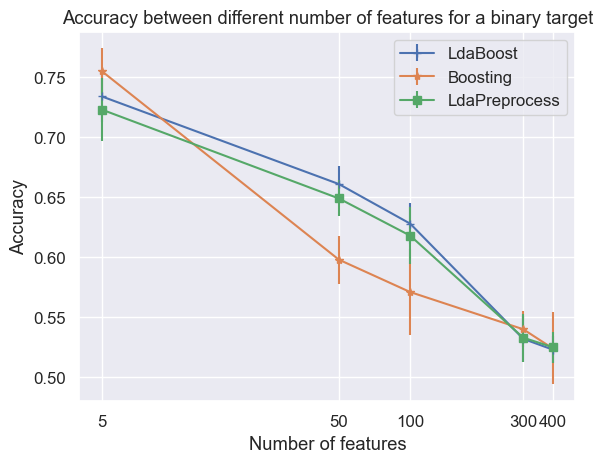

In [32]:
plot = plot_err(n_features, "features", binary_class_results, target_name, dataset_name)

- Come varia l'accuracy al livello di correlazione e al variare delle covariate
- Aggiungere il pre processing con la lda e il gradient boosting

## Accuracy-correlation

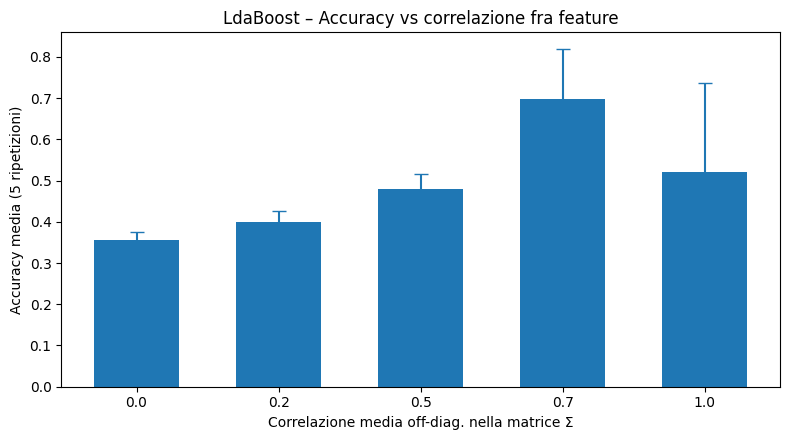

---------------------------------------------------------
 Correlazione   Accuracy media    Dev. standard
---------------------------------------------------------
   0.00        0.3564           0.0197
   0.20        0.4004           0.0260
   0.50        0.4804           0.0360
   0.70        0.6987           0.1199
   1.00        0.5196           0.2160


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# ------------------------------------------------------------
# 1.  Le due funzioni che hai già (copiate pari-pari) ----------
# ------------------------------------------------------------
def make_classification_cov(n_samples, n_features, n_classes,
                            cov=None, shuffle=True, random_state=None):
    rng = np.random.RandomState(random_state)

    n_samples = int(n_samples); n_features = int(n_features); n_classes = int(n_classes)
    if n_samples < 1 or n_features < 1 or n_classes < 1:
        raise ValueError("n_samples, n_features, and n_classes must be positive integers.")

    if cov is None:
        Σ = np.eye(n_features)
    else:
        Σ = np.array(cov)
        if Σ.shape != (n_features, n_features):
            raise ValueError(f"Covariance matrix must be shape ({n_features},{n_features}).")
        if not np.allclose(Σ, Σ.T):
            raise ValueError("Covariance matrix must be symmetric.")

    base, extra = divmod(n_samples, n_classes)
    offset = 1.0
    means = []
    for i in range(n_classes):
        mean_vec = np.zeros(n_features)
        for j in range(n_features):
            if (i >> j) & 1:
                mean_vec[j] = offset
        means.append(mean_vec)
    means = np.array(means)

    X_parts, y_parts = [], []
    for class_idx in range(n_classes):
        count = base + (1 if class_idx < extra else 0)
        if count <= 0:
            continue
        samples = rng.multivariate_normal(mean=means[class_idx], cov=Σ, size=count)
        X_parts.append(samples)
        y_parts.append(np.full(count, class_idx, dtype=int))

    X = np.vstack(X_parts)
    y = np.concatenate(y_parts)

    if shuffle:
        perm = rng.permutation(n_samples)
        X, y = X[perm], y[perm]

    return X, y


def generate_cov_matrix(size: int, mean: float, seed: int = None, std_dev: float = 0.05):
    """Crea una matrice di covarianza simmetrica con 1 sulla diagonale
       e valori ~ Normal(mean, std_dev) tagliata in [-1,1] fuori
       dalla diagonale."""
    if seed is not None:
        np.random.seed(seed)
    a, b = (-1 - mean) / std_dev, (1 - mean) / std_dev
    M = np.eye(size)
    for i in range(size):
        for j in range(i + 1, size):
            v = truncnorm.rvs(a, b, loc=mean, scale=std_dev)
            M[i, j] = M[j, i] = v
    return M
# ------------------------------------------------------------
# 2.  Parametri esperimento ----------------------------------
# ------------------------------------------------------------
correlations   = [0, 0.2, 0.5, 0.7, 1]   # valori richiesti
n_replicates   = 5                       # 5 dataset diversi
n_features     = 10
n_samples      = 1500
n_classes      = 5
test_size      = .30


# ------------------------------------------------------------
# 3.  Loop principale ----------------------------------------
# ------------------------------------------------------------
results = {c: [] for c in correlations}

def make_psd(mat, eps0=1e-8):
    """Rende positiva-definita la matrice aggiungendo
       eps*I fintanto che il tentativo di Cholesky fallisce."""
    eps = eps0
    M = mat.copy()
    while True:
        try:
            np.linalg.cholesky(M)
            return M
        except np.linalg.LinAlgError:
            M += eps * np.eye(M.shape[0])
            eps *= 10

for corr in correlations:
    for rep in range(1, n_replicates + 1):
        # 3.1   Matrice Σ con correlazione media = corr
        Σ = generate_cov_matrix(n_features, mean=corr,
                                seed=rep, std_dev=0.05)
        Σ = make_psd(Σ)          # ci protegge da casi non PSD

        # 3.2   Dataset sintetico
        X, y = make_classification_cov(n_samples=n_samples,
                                       n_features=n_features,
                                       n_classes=n_classes,
                                       cov=Σ,
                                       random_state=rep)

        # 3.3   Train/test split
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size, random_state=1
        )

        # 3.4   LdaBoost
        model = LdaBoost(n_estimators=500,
                         learning_rate=0.05,
                         max_depth=7,
                         random_state=1)
        model.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, model.predict(X_te))
        results[corr].append(acc)

# ------------------------------------------------------------
# 4.  Statistiche & grafico ----------------------------------
# ------------------------------------------------------------
corr_vals = np.array(correlations, dtype=float)
mean_acc  = np.array([np.mean(results[c]) for c in correlations])
std_acc   = np.array([np.std (results[c]) for c in correlations])

# 4.1   Istogramma (bar plot) con barre d'errore
plt.figure(figsize=(8, 4.5))
plt.bar(range(len(corr_vals)), mean_acc, width=0.6)
plt.errorbar(range(len(corr_vals)), mean_acc, yerr=std_acc,
             fmt='none', capsize=5, lw=1.5)
plt.xticks(range(len(corr_vals)), corr_vals)
plt.xlabel('Correlazione media off-diag. nella matrice Σ')
plt.ylabel('Accuracy media (5 ripetizioni)')
plt.title('LdaBoost – Accuracy vs correlazione fra feature')
plt.tight_layout()
plt.show()

# 4.2   Report testuale
print("---------------------------------------------------------")
print(" Correlazione   Accuracy media    Dev. standard")
print("---------------------------------------------------------")
for c, m, s in zip(corr_vals, mean_acc, std_acc):
    print(f" {c:>6.2f}        {m:>6.4f}           {s:>6.4f}")

Plot nfeature vs correlazione (0, 0.2, 0.7)

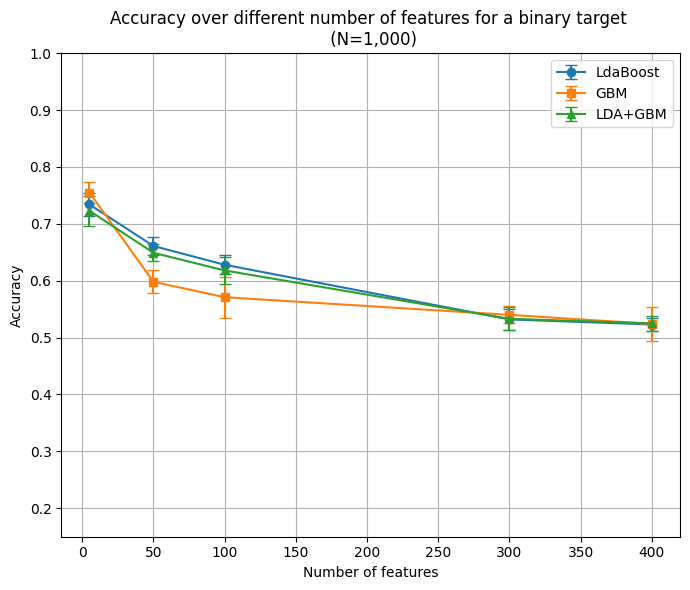

In [10]:
import matplotlib.pyplot as plt

# Numero di feature considerate
features = [5, 50, 100, 300, 400]

# ------------------------------
# Accuratezze e barre d’errore
# ------------------------------
# Boosting (GBM standard)
boost_acc = [0.755, 0.598, 0.571, 0.540, 0.524]
boost_err = [0.019, 0.020, 0.036, 0.015, 0.030]

# LdaBoost
ldaboost_acc = [0.734, 0.661, 0.628, 0.532, 0.523]
ldaboost_err = [0.021, 0.015, 0.017, 0.019, 0.011]

# LdaPreprocess (LDA + GBM)
ldaprep_acc = [0.723, 0.649, 0.618, 0.533, 0.525]
ldaprep_err = [0.026, 0.015, 0.024, 0.020, 0.013]

# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(7, 6))

plt.errorbar(
    features, ldaboost_acc, yerr=ldaboost_err,
    marker='o', linestyle='-', label='LdaBoost', capsize=4
)
plt.errorbar(
    features, boost_acc, yerr=boost_err,
    marker='s', linestyle='-', label='GBM', capsize=4
)
plt.errorbar(
    features, ldaprep_acc, yerr=ldaprep_err,
    marker='^', linestyle='-', label='LDA+GBM', capsize=4
)

# Impostiamo il range dell'asse y
plt.ylim(0.15, 1)

plt.title('Accuracy over different number of features for a binary target \n (N=1,000)')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Accuracy over different number of features for a binary target.pdf")
plt.show()

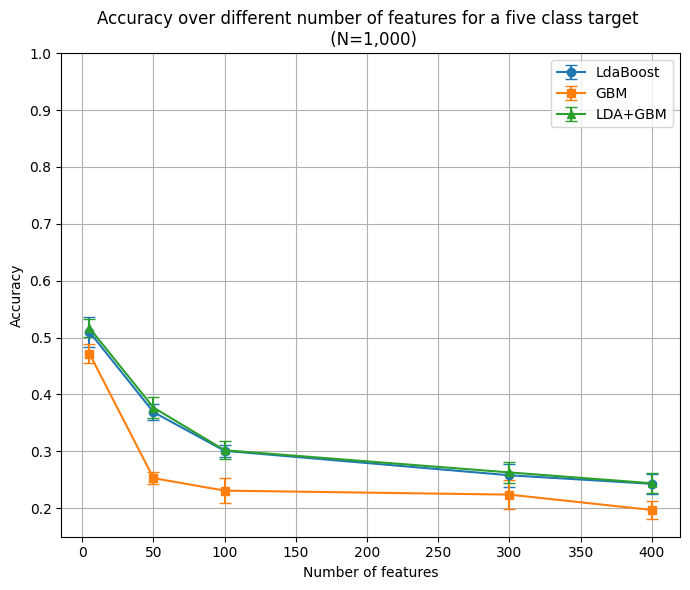

In [ ]:
# ------------
# Boost results:

# [0.472, 0.253, 0.231, 0.224, 0.197] [0.016, 0.01, 0.022, 0.026, 0.015]
# ------------
# LdaBoost results:

# [0.51, 0.369, 0.301, 0.258, 0.243] [0.026, 0.014, 0.01, 0.02, 0.018]
# ------------
# Lda preprocessing results:

# [0.517, 0.377, 0.302, 0.263, 0.244] [0.016, 0.019, 0.016, 0.019, 0.018]


import matplotlib.pyplot as plt

# Numero di feature considerate
features = [5, 50, 100, 300, 400]

# ------------------------------
# Accuratezze e barre d’errore
# ------------------------------
# Boosting (GBM standard)
boost_acc = [0.472, 0.253, 0.231, 0.224, 0.197] 
boost_err = [0.016, 0.01, 0.022, 0.026, 0.015]

# LdaBoost
ldaboost_acc = [0.51, 0.369, 0.301, 0.258, 0.243]
ldaboost_err = [0.026, 0.014, 0.01, 0.02, 0.018]

# LdaPreprocess (LDA + GBM)
ldaprep_acc = [0.517, 0.377, 0.302, 0.263, 0.244]
ldaprep_err = [0.016, 0.019, 0.016, 0.019, 0.018]

# ------------------------------
# Plot
# ------------------------------
plt.figure(figsize=(7, 6))

plt.errorbar(
    features, ldaboost_acc, yerr=ldaboost_err,
    marker='o', linestyle='-', label='LdaBoost', capsize=4
)
plt.errorbar(
    features, boost_acc, yerr=boost_err,
    marker='s', linestyle='-', label='GBM', capsize=4
)
plt.errorbar(
    features, ldaprep_acc, yerr=ldaprep_err,
    marker='^', linestyle='-', label='LDA+GBM', capsize=4
)

# Impostiamo il range dell'asse y
plt.ylim(0.15, 1)

plt.title('Accuracy over different number of features for a five class target \n (N=1,000)')
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("Accuracy over different number of features for a five class target.pdf")
plt.show()